# NB00: Environment Setup & Read Quality Control

This notebook installs required packages, validates input FASTQ files, inspects read properties (length, primers, quality), and runs fastp for comprehensive QC reporting.

**Inputs:** Raw paired-end FASTQ files in `../user_data/16S/` and `../user_data/ITS/`  
**Outputs:** QC summary table (`../data/qc_summary.tsv`), fastp reports (`../data/fastp_reports/`), sample manifest (`../data/sample_manifest.tsv`)

## 1. Install Dependencies

In [1]:
import subprocess, sys

def install_pip(*packages):
    for pkg in packages:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install_pip('plotly', 'scikit-bio')

# Install fastp via conda
subprocess.run(['conda', 'install', '-y', '-c', 'bioconda', 'fastp'], capture_output=True)

# Verify
import plotly; print(f'plotly {plotly.__version__}')
import skbio; print(f'scikit-bio {skbio.__version__}')
!which fastp && fastp --version

plotly 6.7.0


scikit-bio 0.7.2
/opt/conda/bin/fastp
fastp 1.3.3


## 2. Load Sample Metadata & Build Manifest

In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

PROJECT = Path('..').resolve()
DATA_DIR = PROJECT / 'data'
USER_DATA = PROJECT / 'user_data'
FIG_DIR = PROJECT / 'figures'
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

meta = pd.read_csv(DATA_DIR / 'sample_metadata.tsv', sep='\t')
meta = meta.dropna(subset=['sample_id'])
print(f'{len(meta)} samples loaded')
meta

21 samples loaded


,sample_id,sample_number,group,group_label,round,round1_condition,round2_condition,labile_carbon_r1,labile_carbon_r2,r1_history,16S_R1,16S_R2,ITS_R1,ITS_R2
0,Base_1,1,1,Base,0,none,none,no,no,none,zr30398_1V3V4_R1.fastq.gz,zr30398_1V3V4_R2.fastq.gz,zr30398_1ITS2_R1.fastq.gz,zr30398_1ITS2_R2.fastq.gz
1,Base_2,2,1,Base,0,none,none,no,no,none,zr30398_2V3V4_R1.fastq.gz,zr30398_2V3V4_R2.fastq.gz,zr30398_2ITS2_R1.fastq.gz,zr30398_2ITS2_R2.fastq.gz
2,Base_3,3,1,Base,0,none,none,no,no,none,zr30398_3V3V4_R1.fastq.gz,zr30398_3V3V4_R2.fastq.gz,zr30398_3ITS2_R1.fastq.gz,zr30398_3ITS2_R2.fastq.gz
3,L_1,4,2,L,1,lignin,none,no,no,lignin,zr30398_4V3V4_R1.fastq.gz,zr30398_4V3V4_R2.fastq.gz,zr30398_4ITS2_R1.fastq.gz,zr30398_4ITS2_R2.fastq.gz
4,L_2,5,2,L,1,lignin,none,no,no,lignin,zr30398_5V3V4_R1.fastq.gz,zr30398_5V3V4_R2.fastq.gz,zr30398_5ITS2_R1.fastq.gz,zr30398_5ITS2_R2.fastq.gz
5,L_3,6,2,L,1,lignin,none,no,no,lignin,zr30398_6V3V4_R1.fastq.gz,zr30398_6V3V4_R2.fastq.gz,zr30398_6ITS2_R1.fastq.gz,zr30398_6ITS2_R2.fastq.gz
6,LC_1,7,3,LC,1,lignin_labile,none,yes,no,lignin_labile,zr30398_7V3V4_R1.fastq.gz,zr30398_7V3V4_R2.fastq.gz,zr30398_7ITS2_R1.fastq.gz,zr30398_7ITS2_R2.fastq.gz
7,LC_2,8,3,LC,1,lignin_labile,none,yes,no,lignin_labile,zr30398_8V3V4_R1.fastq.gz,zr30398_8V3V4_R2.fastq.gz,zr30398_8ITS2_R1.fastq.gz,zr30398_8ITS2_R2.fastq.gz
8,LC_3,9,3,LC,1,lignin_labile,none,yes,no,lignin_labile,zr30398_9V3V4_R1.fastq.gz,zr30398_9V3V4_R2.fastq.gz,zr30398_9ITS2_R1.fastq.gz,zr30398_9ITS2_R2.fastq.gz
9,LL_1,10,4,L-L,2,lignin,lignin,no,no,lignin,zr30398_10V3V4_R1.fastq.gz,zr30398_10V3V4_R2.fastq.gz,zr30398_10ITS2_R1.fastq.gz,zr30398_10ITS2_R2.fastq.gz


In [3]:
# Build manifest: map each fastq file to its sample and group
rows = []
for _, row in meta.iterrows():
    sid = row['sample_id']
    snum = int(row['sample_number'])
    group = int(row['group'])
    label = row['group_label']
    
    for marker, tag in [('16S', 'V3V4'), ('ITS', 'ITS2')]:
        r1 = USER_DATA / marker / f'zr30398_{snum}{tag}_R1.fastq'
        r2 = USER_DATA / marker / f'zr30398_{snum}{tag}_R2.fastq'
        rows.append({
            'sample_id': sid,
            'sample_number': snum,
            'group': group,
            'group_label': label,
            'marker': marker,
            'R1_path': str(r1),
            'R2_path': str(r2),
            'R1_exists': r1.exists(),
            'R2_exists': r2.exists(),
        })

manifest = pd.DataFrame(rows)
print(f'Manifest: {len(manifest)} libraries ({manifest.R1_exists.sum()} R1 present, {manifest.R2_exists.sum()} R2 present)')
assert manifest.R1_exists.all() and manifest.R2_exists.all(), 'Missing files!'
print('All files present.')
manifest.to_csv(DATA_DIR / 'sample_manifest.tsv', sep='\t', index=False)
manifest.head()

Manifest: 42 libraries (42 R1 present, 42 R2 present)
All files present.


,sample_id,sample_number,group,group_label,marker,R1_path,R2_path,R1_exists,R2_exists
0,Base_1,1,1,Base,16S,/home/raad0102/BERIL-research-observatory/proj...,/home/raad0102/BERIL-research-observatory/proj...,True,True
1,Base_1,1,1,Base,ITS,/home/raad0102/BERIL-research-observatory/proj...,/home/raad0102/BERIL-research-observatory/proj...,True,True
2,Base_2,2,1,Base,16S,/home/raad0102/BERIL-research-observatory/proj...,/home/raad0102/BERIL-research-observatory/proj...,True,True
3,Base_2,2,1,Base,ITS,/home/raad0102/BERIL-research-observatory/proj...,/home/raad0102/BERIL-research-observatory/proj...,True,True
4,Base_3,3,1,Base,16S,/home/raad0102/BERIL-research-observatory/proj...,/home/raad0102/BERIL-research-observatory/proj...,True,True


## 3. Read Counts & File Sizes

In [4]:
def count_reads(fastq_path):
    """Count reads in an uncompressed FASTQ file."""
    n = 0
    with open(fastq_path) as f:
        for _ in f:
            n += 1
    return n // 4

qc_rows = []
for _, row in manifest.iterrows():
    r1_reads = count_reads(row['R1_path'])
    r2_reads = count_reads(row['R2_path'])
    r1_size = os.path.getsize(row['R1_path'])
    r2_size = os.path.getsize(row['R2_path'])
    qc_rows.append({
        'sample_id': row['sample_id'],
        'group_label': row['group_label'],
        'marker': row['marker'],
        'R1_reads': r1_reads,
        'R2_reads': r2_reads,
        'paired': r1_reads == r2_reads,
        'R1_size_MB': r1_size / 1e6,
        'R2_size_MB': r2_size / 1e6,
    })

qc = pd.DataFrame(qc_rows)
print(f'All R1/R2 paired: {qc.paired.all()}')
print(f'\n16S read count range: {qc[qc.marker=="16S"].R1_reads.min():,} – {qc[qc.marker=="16S"].R1_reads.max():,}')
print(f'ITS read count range: {qc[qc.marker=="ITS"].R1_reads.min():,} – {qc[qc.marker=="ITS"].R1_reads.max():,}')
qc

All R1/R2 paired: True

16S read count range: 30,769 – 111,565
ITS read count range: 7,089 – 202,752


,sample_id,group_label,marker,R1_reads,R2_reads,paired,R1_size_MB,R2_size_MB
0,Base_1,Base,16S,42630,42630,True,28.860510,28.860510
1,Base_1,Base,ITS,119900,119900,True,81.172300,81.172300
2,Base_2,Base,16S,61234,61234,True,41.455418,41.455418
3,Base_2,Base,ITS,87356,87356,True,59.140012,59.140012
4,Base_3,Base,16S,52676,52676,True,35.661652,35.661652
5,Base_3,Base,ITS,103493,103493,True,70.064761,70.064761
6,L_1,L,16S,82206,82206,True,55.653462,55.653462
7,L_1,L,ITS,169043,169043,True,114.442111,114.442111
8,L_2,L,16S,60744,60744,True,41.123688,41.123688
9,L_2,L,ITS,148140,148140,True,100.290780,100.290780


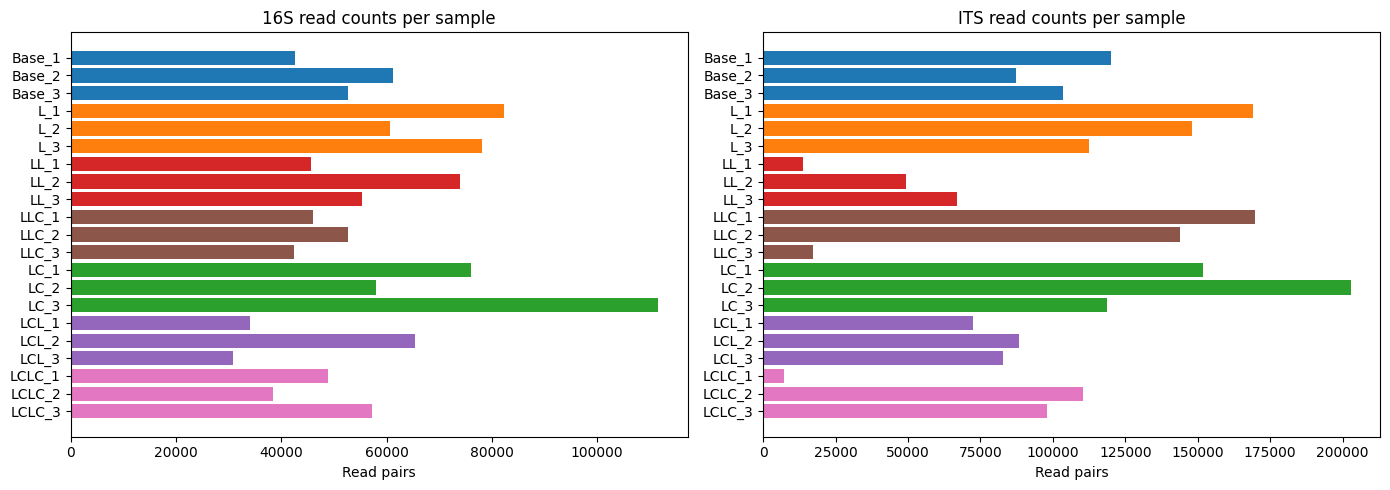

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, marker in zip(axes, ['16S', 'ITS']):
    sub = qc[qc.marker == marker].sort_values('group_label')
    colors = sub['group_label'].map({
        'Base': '#1f77b4', 'L': '#ff7f0e', 'LC': '#2ca02c',
        'L-L': '#d62728', 'LC-L': '#9467bd', 'L-LC': '#8c564b', 'LC-LC': '#e377c2'
    })
    ax.barh(sub['sample_id'], sub['R1_reads'], color=colors)
    ax.set_xlabel('Read pairs')
    ax.set_title(f'{marker} read counts per sample')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'read_counts_per_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Read Length & Primer Inspection

In [6]:
from Bio import SeqIO

PRIMERS = {
    '16S_F': 'CCTACGGGNGGCWGCAG',     # 341F
    '16S_R': 'GACTACHVGGGTATCTAATCC',  # 805R
    'ITS_F': 'GCATCGATGAAGAACGCAGC',   # ITS3
    'ITS_R': 'TCCTCCGCTTATTGATATGC',   # ITS4
}

def inspect_reads(fastq_path, n=1000):
    """Sample first n reads: get length distribution and check for primer at start."""
    lengths = []
    with open(fastq_path) as f:
        for i, rec in enumerate(SeqIO.parse(f, 'fastq')):
            if i >= n:
                break
            lengths.append(len(rec.seq))
    return lengths

def check_primer(fastq_path, primer_seq, n=100):
    """Check what fraction of first n reads start with the primer (allowing 1 mismatch)."""
    from Bio.Seq import Seq
    hits = 0
    total = 0
    plen = len(primer_seq)
    with open(fastq_path) as f:
        for i, rec in enumerate(SeqIO.parse(f, 'fastq')):
            if i >= n:
                break
            total += 1
            read_start = str(rec.seq[:plen])
            mismatches = sum(1 for a, b in zip(read_start, primer_seq) if a != b and b not in 'NWYHVD')
            if mismatches <= 1:
                hits += 1
    return hits / total if total > 0 else 0

# Inspect one sample per marker
for marker, tag, fwd_key, rev_key in [('16S', 'V3V4', '16S_F', '16S_R'), ('ITS', 'ITS2', 'ITS_F', 'ITS_R')]:
    r1_path = str(USER_DATA / marker / f'zr30398_1{tag}_R1.fastq')
    r2_path = str(USER_DATA / marker / f'zr30398_1{tag}_R2.fastq')
    
    r1_lens = inspect_reads(r1_path)
    r2_lens = inspect_reads(r2_path)
    
    fwd_hit = check_primer(r1_path, PRIMERS[fwd_key])
    rev_hit = check_primer(r2_path, PRIMERS[rev_key])
    
    print(f'=== {marker} (sample 1) ===')
    print(f'  R1 length: {min(r1_lens)}-{max(r1_lens)} bp (median {np.median(r1_lens):.0f})')
    print(f'  R2 length: {min(r2_lens)}-{max(r2_lens)} bp (median {np.median(r2_lens):.0f})')
    print(f'  Forward primer ({fwd_key}) in R1: {fwd_hit:.0%}')
    print(f'  Reverse primer ({rev_key}) in R2: {rev_hit:.0%}')
    print()

=== 16S (sample 1) ===
  R1 length: 301-301 bp (median 301)
  R2 length: 301-301 bp (median 301)
  Forward primer (16S_F) in R1: 0%
  Reverse primer (16S_R) in R2: 0%

=== ITS (sample 1) ===
  R1 length: 301-301 bp (median 301)
  R2 length: 301-301 bp (median 301)
  Forward primer (ITS_F) in R1: 100%
  Reverse primer (ITS_R) in R2: 97%



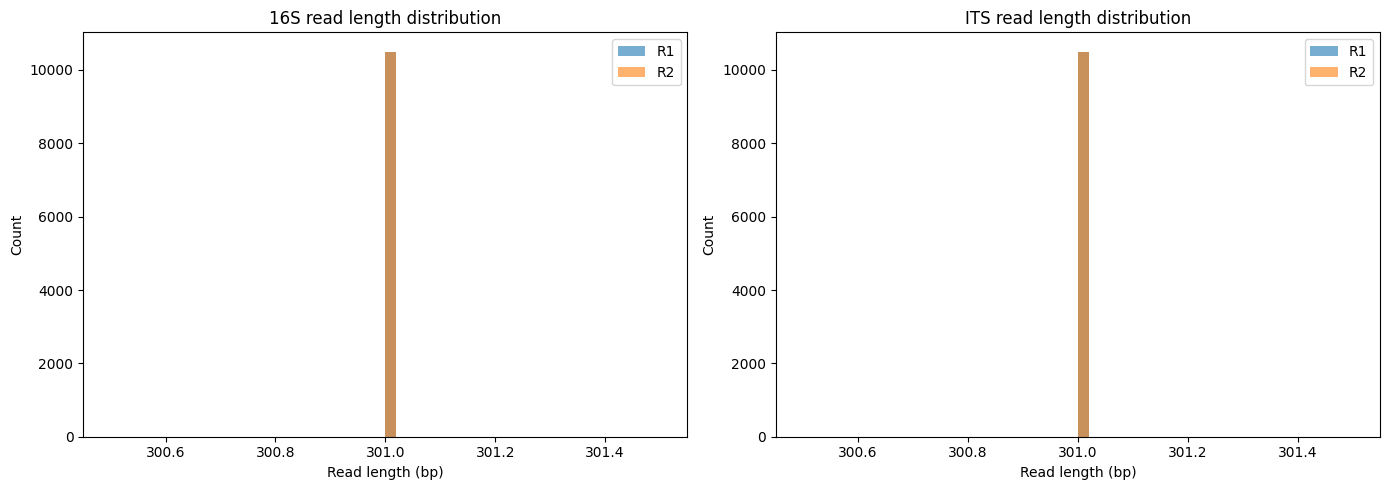

In [7]:
# Read length distribution across ALL samples
length_data = []
for _, row in manifest.iterrows():
    r1_lens = inspect_reads(row['R1_path'], n=500)
    for l in r1_lens:
        length_data.append({'sample_id': row['sample_id'], 'marker': row['marker'], 'read': 'R1', 'length': l})
    r2_lens = inspect_reads(row['R2_path'], n=500)
    for l in r2_lens:
        length_data.append({'sample_id': row['sample_id'], 'marker': row['marker'], 'read': 'R2', 'length': l})

len_df = pd.DataFrame(length_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, marker in zip(axes, ['16S', 'ITS']):
    sub = len_df[len_df.marker == marker]
    for read, color in [('R1', '#1f77b4'), ('R2', '#ff7f0e')]:
        ax.hist(sub[sub.read == read]['length'], bins=50, alpha=0.6, label=read, color=color)
    ax.set_xlabel('Read length (bp)')
    ax.set_ylabel('Count')
    ax.set_title(f'{marker} read length distribution')
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'read_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Run fastp QC

In [8]:
import json, subprocess

fastp_dir = DATA_DIR / 'fastp_reports'
fastp_dir.mkdir(exist_ok=True)

fastp_results = []

for _, row in manifest.iterrows():
    sid = row['sample_id']
    marker = row['marker']
    json_out = fastp_dir / f'{sid}_{marker}_fastp.json'
    html_out = fastp_dir / f'{sid}_{marker}_fastp.html'
    
    cmd = [
        'fastp',
        '-i', row['R1_path'],
        '-I', row['R2_path'],
        '-j', str(json_out),
        '-h', str(html_out),
        '--disable_adapter_trimming',
        '--disable_quality_filtering',
        '--disable_length_filtering',
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if json_out.exists():
        with open(json_out) as f:
            j = json.load(f)
        s = j['summary']['before_filtering']
        fastp_results.append({
            'sample_id': sid,
            'marker': marker,
            'total_reads': s['total_reads'],
            'total_bases': s['total_bases'],
            'q20_rate': s['q20_rate'],
            'q30_rate': s['q30_rate'],
            'gc_content': s['gc_content'],
            'read1_mean_length': j['read1_before_filtering']['total_bases'] / j['read1_before_filtering']['total_reads'] if j['read1_before_filtering']['total_reads'] > 0 else 0,
            'read2_mean_length': j['read2_before_filtering']['total_bases'] / j['read2_before_filtering']['total_reads'] if j['read2_before_filtering']['total_reads'] > 0 else 0,
        })
    else:
        print(f'FAILED: {sid} {marker}: {result.stderr[:200]}')

fastp_df = pd.DataFrame(fastp_results)
print(f'fastp completed for {len(fastp_df)} / {len(manifest)} libraries')
fastp_df

fastp completed for 42 / 42 libraries


,sample_id,marker,total_reads,total_bases,q20_rate,q30_rate,gc_content,read1_mean_length,read2_mean_length
0,Base_1,16S,85260,25663260,0.995887,0.985123,0.575982,301.0,301.0
1,Base_1,ITS,239800,72179800,0.994609,0.978814,0.542784,301.0,301.0
2,Base_2,16S,122468,36862868,0.995083,0.982789,0.576311,301.0,301.0
3,Base_2,ITS,174712,52588312,0.995541,0.981611,0.545434,301.0,301.0
4,Base_3,16S,105352,31710952,0.995599,0.984694,0.576200,301.0,301.0
5,Base_3,ITS,206986,62302786,0.994871,0.979541,0.537780,301.0,301.0
6,L_1,16S,164412,49488012,0.995378,0.984333,0.525648,301.0,301.0
7,L_1,ITS,338086,101763886,0.995361,0.980906,0.550427,301.0,301.0
8,L_2,16S,121488,36567888,0.995085,0.983869,0.525655,301.0,301.0
9,L_2,ITS,296280,89180280,0.994141,0.977191,0.564529,301.0,301.0


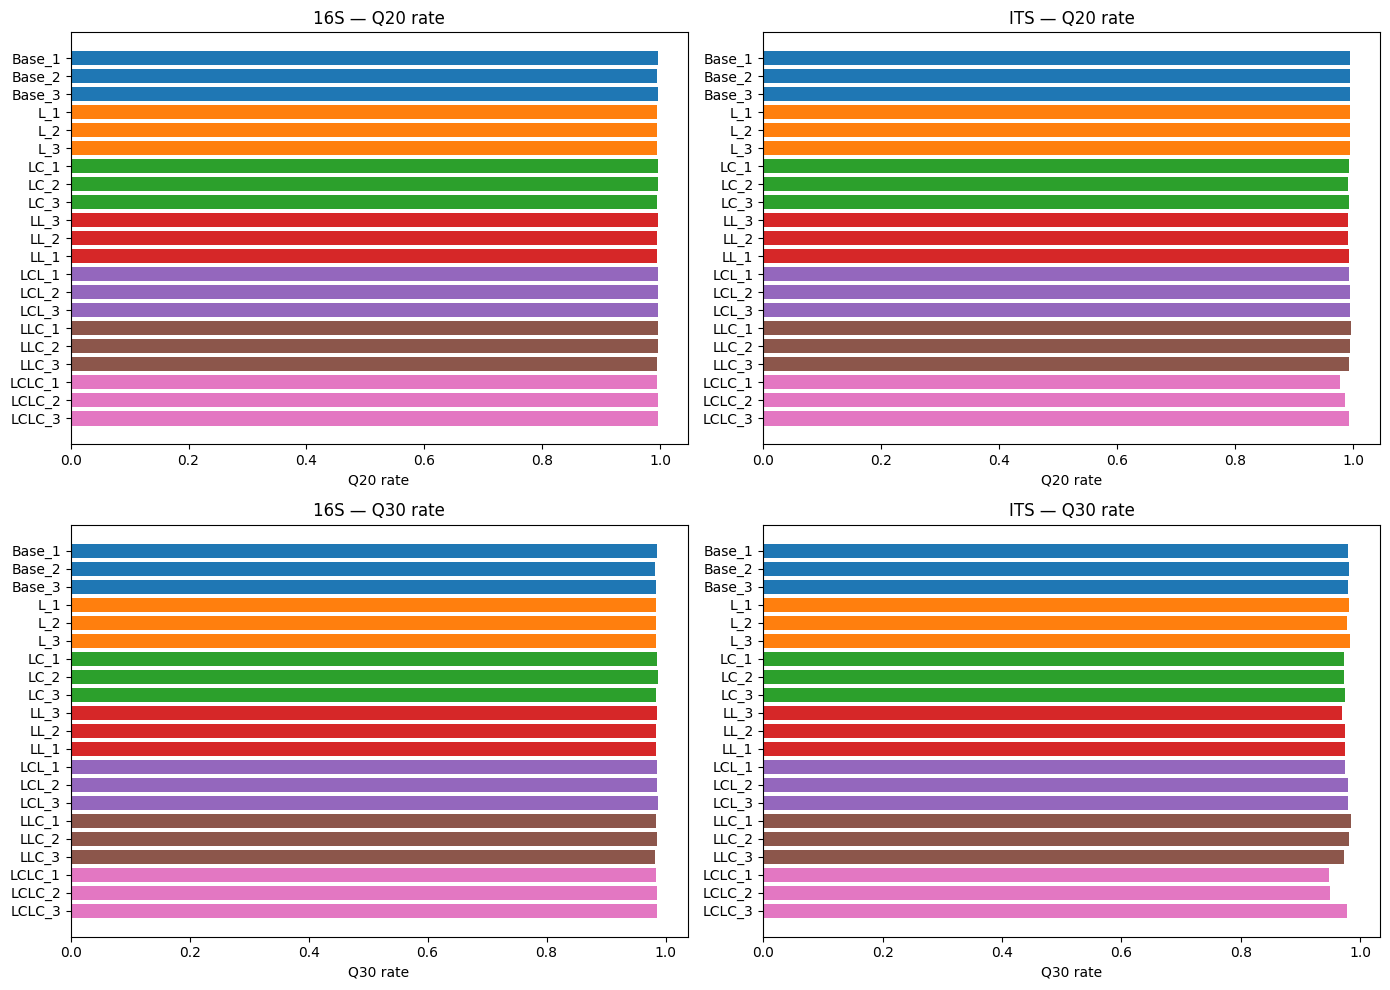

In [9]:
# Quality summary plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (ax_row, metric, ylabel) in enumerate([
    (axes[0], 'q20_rate', 'Q20 rate'),
    (axes[1], 'q30_rate', 'Q30 rate'),
]):
    for ax, marker in zip(ax_row, ['16S', 'ITS']):
        sub = fastp_df[fastp_df.marker == marker].merge(
            meta[['sample_id', 'group_label']], on='sample_id'
        )
        group_order = ['Base', 'L', 'LC', 'L-L', 'LC-L', 'L-LC', 'LC-LC']
        sub['group_label'] = pd.Categorical(sub['group_label'], categories=group_order, ordered=True)
        sub = sub.sort_values('group_label')
        colors = sub['group_label'].map({
            'Base': '#1f77b4', 'L': '#ff7f0e', 'LC': '#2ca02c',
            'L-L': '#d62728', 'LC-L': '#9467bd', 'L-LC': '#8c564b', 'LC-LC': '#e377c2'
        })
        ax.barh(sub['sample_id'], sub[metric], color=colors)
        ax.set_xlabel(ylabel)
        ax.set_title(f'{marker} — {ylabel}')
        ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_DIR / 'quality_scores_summary.png', dpi=150, bbox_inches='tight')
plt.show()

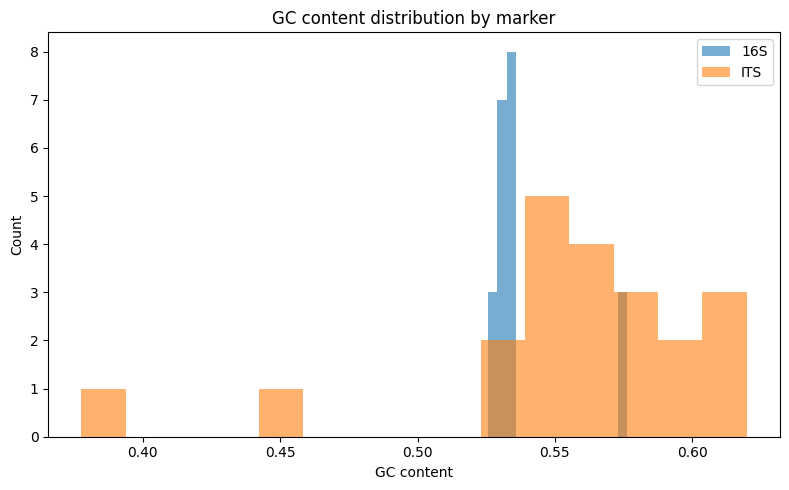

In [10]:
# GC content by marker
fig, ax = plt.subplots(figsize=(8, 5))
for marker, color in [('16S', '#1f77b4'), ('ITS', '#ff7f0e')]:
    sub = fastp_df[fastp_df.marker == marker]
    ax.hist(sub['gc_content'], bins=15, alpha=0.6, label=marker, color=color)
ax.set_xlabel('GC content')
ax.set_ylabel('Count')
ax.set_title('GC content distribution by marker')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'gc_content_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. QC Summary

In [11]:
# Merge QC data and save
qc_final = qc.merge(fastp_df[['sample_id', 'marker', 'q20_rate', 'q30_rate', 'gc_content', 
                               'read1_mean_length', 'read2_mean_length']], 
                     on=['sample_id', 'marker'], how='left')
qc_final.to_csv(DATA_DIR / 'qc_summary.tsv', sep='\t', index=False)

print('=== QC Summary ===')
for marker in ['16S', 'ITS']:
    sub = qc_final[qc_final.marker == marker]
    print(f'\n{marker}:')
    print(f'  Samples: {len(sub)}')
    print(f'  Read pairs: {sub.R1_reads.min():,} – {sub.R1_reads.max():,} (median {sub.R1_reads.median():,.0f})')
    print(f'  R1 mean length: {sub.read1_mean_length.mean():.1f} bp')
    print(f'  R2 mean length: {sub.read2_mean_length.mean():.1f} bp')
    print(f'  Q20 rate: {sub.q20_rate.mean():.3f} (min {sub.q20_rate.min():.3f})')
    print(f'  Q30 rate: {sub.q30_rate.mean():.3f} (min {sub.q30_rate.min():.3f})')
    print(f'  GC content: {sub.gc_content.mean():.3f}')
    print(f'  All paired: {sub.paired.all()}')

print(f'\nQC table saved to: {DATA_DIR / "qc_summary.tsv"}')
print(f'fastp reports saved to: {fastp_dir}/')

=== QC Summary ===

16S:
  Samples: 21
  Read pairs: 30,769 – 111,565 (median 55,267)
  R1 mean length: 301.0 bp
  R2 mean length: 301.0 bp
  Q20 rate: 0.996 (min 0.995)
  Q30 rate: 0.985 (min 0.982)
  GC content: 0.538
  All paired: True

ITS:
  Samples: 21
  Read pairs: 7,089 – 202,752 (median 103,493)
  R1 mean length: 301.0 bp
  R2 mean length: 301.0 bp
  Q20 rate: 0.993 (min 0.979)
  Q30 rate: 0.974 (min 0.947)
  GC content: 0.557
  All paired: True

QC table saved to: /home/raad0102/BERIL-research-observatory/projects/lignin_community_enrichment/data/qc_summary.tsv
fastp reports saved to: /home/raad0102/BERIL-research-observatory/projects/lignin_community_enrichment/data/fastp_reports/


In [12]:
# Flag any samples with potential issues
print('=== Sample Flags ===')
issues = []
for _, row in qc_final.iterrows():
    flags = []
    if row['R1_reads'] < 10000:
        flags.append(f'low reads ({row["R1_reads"]:,})')
    if pd.notna(row.get('q30_rate')) and row['q30_rate'] < 0.7:
        flags.append(f'low Q30 ({row["q30_rate"]:.3f})')
    if flags:
        issues.append(f'  {row["sample_id"]} ({row["marker"]}): {", ".join(flags)}')

if issues:
    print('\n'.join(issues))
else:
    print('No issues detected — all samples pass basic QC thresholds.')

=== Sample Flags ===
  LCLC_1 (ITS): low reads (7,089)
